In [1]:
# Biblioteca para operações numéricas
import numpy as np

# Para visualização
import matplotlib.pyplot as plt

# Para redes neurais
import tensorflow as tf

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, \
 Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

# Carregar a base de Dados CIFAR-10

In [2]:
# Carregar a base CIFAR
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalo [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y vem como coluna.
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo",
               "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de X_train: ", X_train.shape)
print(f"Formato de y_train: ", y_train.shape)
print(f"Formato de X_test: ", X_test.shape)
print(f"Formato de y_test: ", y_test.shape)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1045s 6us/step
Formato de X_train:  (50000, 32, 32, 3)
Formato de y_train:  (50000,)
Formato de X_test:  (10000, 32, 32, 3)
Formato de y_test:  (10000,)


# Plotar Algumas Imagens

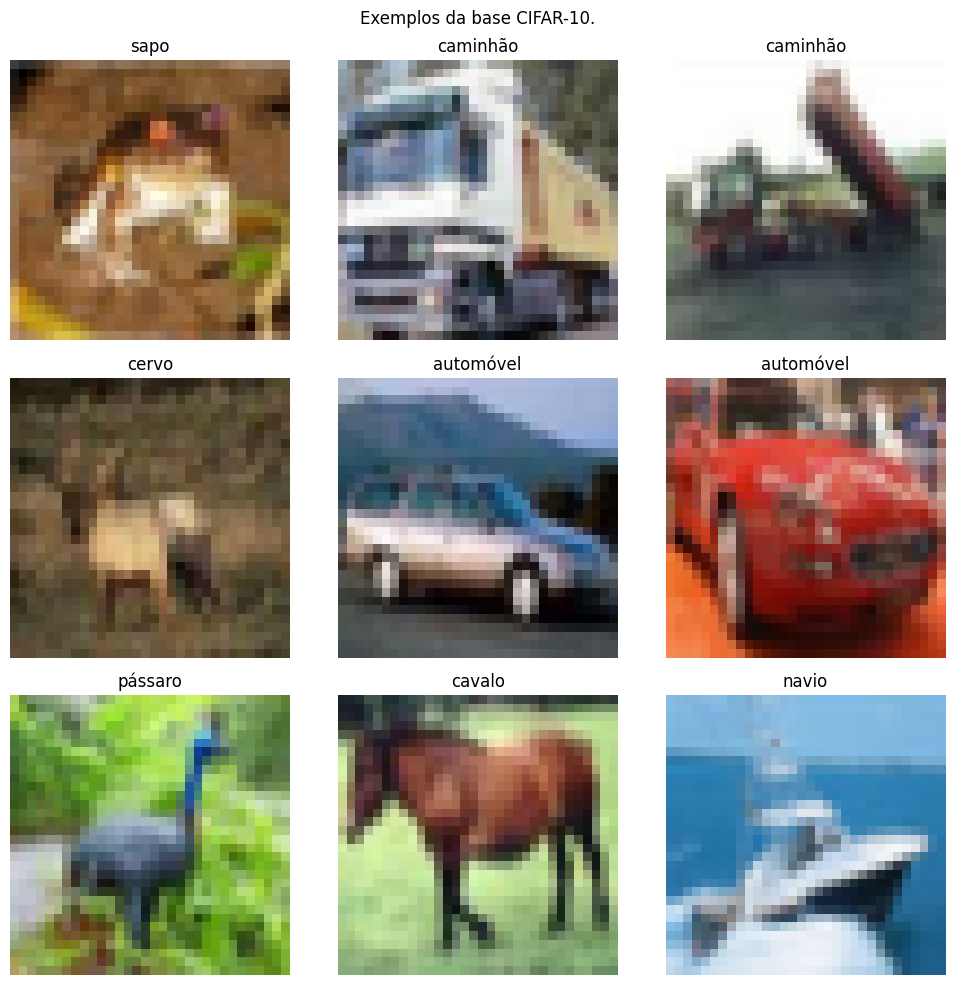

In [3]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Exemplos da base CIFAR-10.")
plt.tight_layout()
plt.show()

# Criação do Modelo CNN

In [4]:
from tensorflow import keras
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

model = keras.Sequential()

# Entrada
model.add(Input(shape=(32, 32, 3)))

# -------------------------
# Bloco 1
# -------------------------
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


# -------------------------
# Bloco 2
# -------------------------
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


# -------------------------
# Bloco 3
# -------------------------
model.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.30))


# -------------------------
# CNN → Rede totalmente conectada
# -------------------------
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# CIFAR-10 possui 10 classes
model.add(Dense(10, activation='softmax'))


# -------------------------
# Compilação
# -------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

# Treinar a Rede

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, # Se a val_loss não melhorar por 3 épocas consecutivas, o treinamento para.
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7915 - loss: 0.6005 - val_accuracy: 0.7220 - val_loss: 0.8190
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8156 - loss: 0.5330 - val_accuracy: 0.8125 - val_loss: 0.5654
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8290 - loss: 0.4975 - val_accuracy: 0.7703 - val_loss: 0.6812
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8403 - loss: 0.4676 - val_accuracy: 0.7981 - val_loss: 0.5843
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8457 - loss: 0.4445 - val_accuracy: 0.8241 - val_loss: 0.5329
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8561 - loss: 0.4174 - val_accuracy: 0.8261 - val_loss: 0.5142
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8662 - loss: 0.3937 - val_accuracy: 0.8364 - val_loss: 0.5018
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8704 - loss: 0

# Plot da Acurácia e Loss

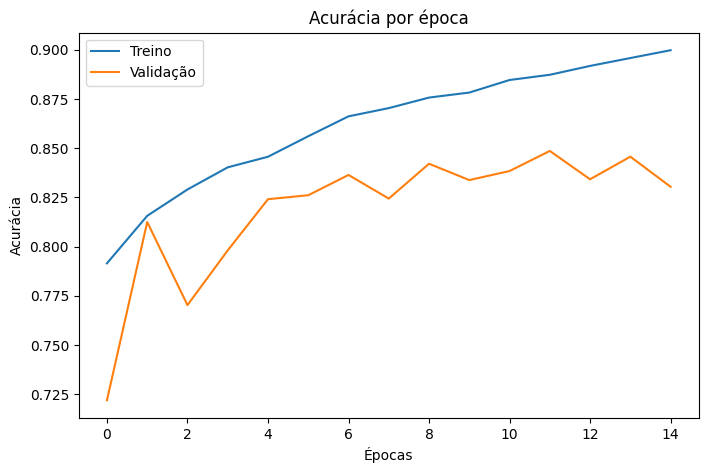

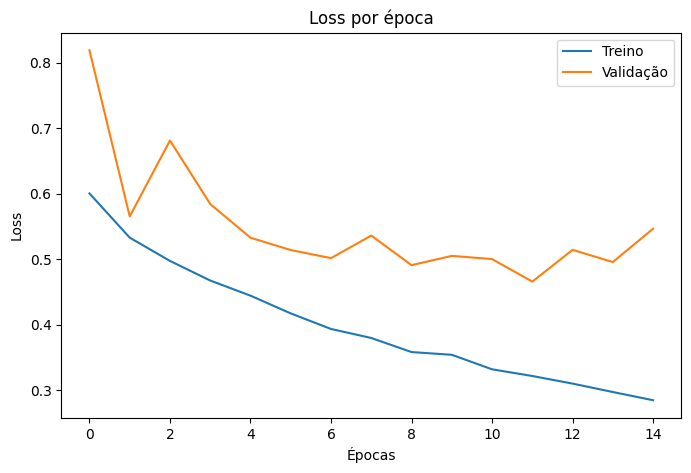

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Treino")
plt.plot(history.history['val_accuracy'], label="Validação")
plt.title("Acurácia por época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label="Treino")
plt.plot(history.history['val_loss'], label="Validação")
plt.title("Loss por época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Realizando Predições

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc:.2}")
print(f"Loss no test: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8392 - loss: 0.4877
Acurácia no conjunto de teste: 0.84
Loss no test: 0.4877


# Previsões em Imagens do Teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


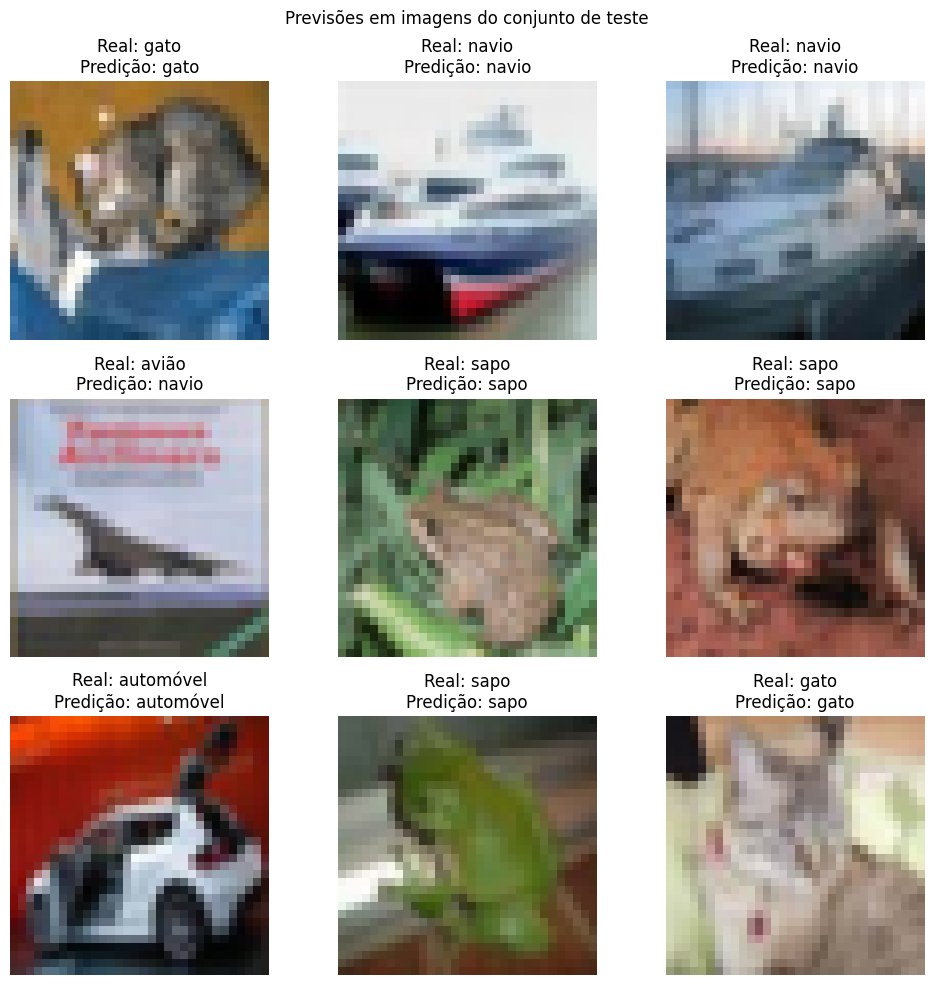

In [13]:
pred_probs = model.predict(X_test[:9])
pred_labels = np.argmax(pred_probs, axis=1)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels[i]]
    plt.title(f"Real: {real}\nPredição: {pred}")
    plt.axis('off')
plt.suptitle("Previsões em imagens do conjunto de teste")
plt.tight_layout()
plt.show()